In [1]:
from astropy.io import fits
import os

In [11]:
fits_dir_blue = '/home/calder/Documents/atmo-analysis-main/data/20190504_KELT-20b/'
fits_dir_red = fits_dir_blue + 'molecfit_weak/'

fits_files_blue = [f for f in os.listdir(fits_dir_blue) if (f.startswith('pepsib')) and (f.endswith('.nor'))]
fits_files_red = [f for f in os.listdir(fits_dir_red) if (f.startswith('SCIENCE')) and (f.endswith('.fits'))]




/home/calder/Documents/atmo-analysis-main/data/20190504_KELT-20b/molecfit_weak/


[-0.02278301 -0.02039975 -0.01811315 -0.01582842 -0.01354452 -0.01126112
 -0.00897614 -0.00669129 -0.00440655 -0.00212308  0.00016025  0.00244488
  0.0047294   0.00701197  0.01370127  0.01598425  0.01826654  0.02055081
  0.02283463  0.02758574  0.0298716 ]
[-0.02278299 -0.02039973 -0.01811508 -0.01583088 -0.01354681 -0.01126345
 -0.00897973 -0.00669624 -0.00441349 -0.00213068  0.00015245  0.00243533
  0.00471838  0.00700384  0.01370129  0.0159869   0.01827008  0.02055352
  0.02283771  0.02758575  0.02986964]


In [17]:
fits_blue = fits_dir_blue + 'pepsib.20190504.034.dxt.nor'

with fits.open(fits_blue) as hdul:
    # Iterate through each HDU (Header/Data Unit) in the FITS file
    for i, hdu in enumerate(hdul):
        print(f"HDU {i}:")
        header = hdu.header
        for key, value in header.items():
            print(f"{key}: {value}")
        print("\n")

HDU 0:
SIMPLE: True
BITPIX: 8
NAXIS: 0
EXTEND: True
: 
MOSAIC: True
DETSIZE: [1:10560,1:10560]
DETECTOR: STA1600LN
: 
GAIN1: 1.536125
GAIN2: 1.546072
GAIN3: 1.538015
GAIN4: 1.537891
GAIN5: 1.550995
GAIN6: 1.534565
GAIN7: 1.537363
GAIN8: 1.539736
GAIN9: 1.520907
GAIN10: 1.528906
GAIN11: 1.524071
GAIN12: 1.532027
GAIN13: 1.545255
GAIN14: 1.550744
GAIN15: 1.544412
GAIN16: 1.543185
: 
GAINS1: 0.594025
GAINS2: 0.636472
GAINS3: 0.593514
GAINS4: 0.596903
GAINS5: 0.559327
GAINS6: 0.599894
GAINS7: 0.595746
GAINS8: 0.618524
GAINS9: 0.528428
GAINS10: 0.62933
GAINS11: 0.619591
GAINS12: 0.662098
GAINS13: 0.631348
GAINS14: 0.616472
GAINS15: 0.587165
GAINS16: 0.607587
: 
READOUT: 77.263
TRANSFER: 4.62
ARM: Blue
: 
CCDTEMP1: 153.0003
CCDTEMP2: 151.9137
CCDTEMP3: 152.0775
DEWATEMP: 109.6532
DEWARPRE: 2414.885
DEWARATE: 15.2
: 
DATE-OBS: 04/05/2019
UT-OBS: 10:59:29.1
EXPTIME: 00:10:00.000
: 
INSTRUME: PEPSI
ORIGIN: SDS
: 
CHAPRESS: 699.9997
CHATEMPE: 19.7855
CHAHUMID: 1.8594
CHARAVE: 2480.614
: 
IMAGETY

Number of observations is not the same for blue and red


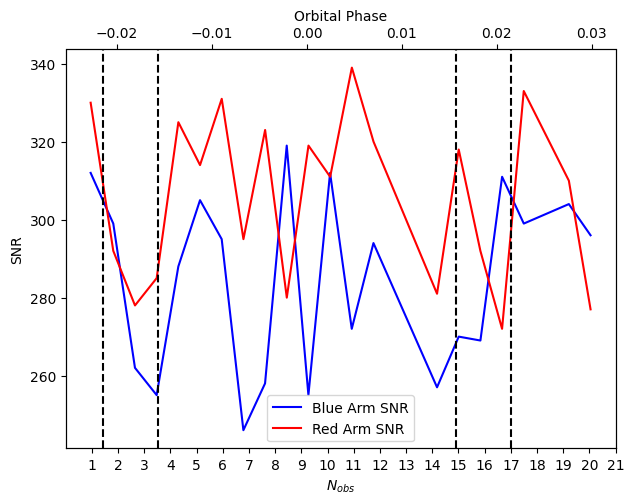

In [57]:
import numpy as np
import matplotlib.pyplot as pl
from uncertainties import ufloat
from uncertainties import unumpy as unp

MJoMS = 1./1047. #MJ in MSun
snr_blue = np.array([])
snr_red = np.array([])


orbital_phase_red = np.load('data_products/KELT-20b.20190504.' + 'red' + '.' + 'Fe' + '.CCFs-raw.npy.phase.npy')
orbital_phase_blue = np.load('data_products/KELT-20b.20190504.' + 'blue' + '.' + 'Fe' + '.CCFs-raw.npy.phase.npy')


Period = ufloat(3.4741070, 0.0000019) # Lund et al. 2017
#Period = ufloat(3.4741085, 0.0000019) # Lund et al. 2017
epoch = ufloat(2457503.120049, 0.000190) #Lund et al. 2017
#epoch = ufloat(2457485.74965, 0.000190) #Lund et al. 2017

M_star = ufloat(1.76, 0.19) #MSun
RV_abs = ufloat(0.0, 0.0) #km/s
i = ufloat(86.12, 0.28) #degrees
M_p = 3.382 #3-sigma limit
R_p = 1.741

RA = '19h38m38.74s'
Dec = '+31d13m09.12s'

dur = 0.14898 #d, Lund et al. 2017

Ks_expected = 0.0

half_duration_phase = (dur/2.)/Period.n
Kp_expected = 28.4329 * M_star/MJoMS * unp.sin(i*np.pi/180.) * (M_star + M_p * MJoMS) ** (-2./3.) * (Period/365.25) ** (-1./3.) / 1000. #to km/s
half_duration_phase = (dur/2.)/Period.n


ingress_egress_dur = 0.01996 #days, Lund et al 2018
ingress_egress_phase = ingress_egress_dur/3.4741085 # Lund et al 2018

orbital_phase_1_red = orbital_phase_red[(orbital_phase_red >= -half_duration_phase ) & (orbital_phase_red <= -half_duration_phase+ingress_egress_phase)]
orbital_phase_2_red = orbital_phase_red[(orbital_phase_red >= half_duration_phase-ingress_egress_phase) & (orbital_phase_red <= half_duration_phase)]

i=0
for fits_file in fits_files_blue:
    i+=1
    fits_path = os.path.join(fits_dir_blue, fits_file)  # join each file name with the directory path
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        for key, value in hdr.items():
            if key == 'SNR':
                snr_blue = np.append(snr_blue, value)

i=0
for fits_file in fits_files_red:
    i+=1
    fits_path = os.path.join(fits_dir_red, fits_file)  # join each file name with the directory path
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        for key, value in hdr.items():
            if key == 'SNR':
                snr_red = np.append(snr_red, value)

n_obs = range(1, len(snr_blue)+1)

#check that the number of observations is the same for both blue and red
if n_obs != len(snr_red):
    print('Number of observations is not the same for blue and red')
#else:
    #pl.plot(n_obs, snr_blue, 'b-o', label='Blue')
    #pl.plot(n_obs, snr_red, 'r-o', label='Red')
    pl.ylabel('SNR')
    pl.xlabel('$N_{obs}$')
    pl.xticks(n_obs)
    # add second x ticks
    pl.tight_layout()
    
    
    ax1 = pl.gca()
    ax2 = ax1.twiny()
    breakpoint()
     #Plot on the second x-axis
    ax2.plot(orbital_phase_blue, snr_blue, 'b-', label='Blue Arm SNR')
    ax2.plot(orbital_phase_red, snr_red, 'r-', label='Red Arm SNR')
    ax2.axvline(x=-half_duration_phase, color='k', linestyle='--')
    ax2.axvline(x=-half_duration_phase+ingress_egress_phase, color='k', linestyle='--')
    ax2.axvline(x=half_duration_phase, color='k', linestyle='--')
    ax2.axvline(x=half_duration_phase-ingress_egress_phase, color='k', linestyle='--')

    ax2.legend()
    # Set the labels for the second x-axis
    ax2.set_xlabel('Orbital Phase')
    
    pl.savefig('plots/SNR.pdf')

In [24]:
i=0
for fits_file in fits_files_blue:
    i+=1
    fits_path = os.path.join(fits_dir_blue, fits_file)  # join each file name with the directory path
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        for key, value in hdr.items():
            if key == 'RADVEL':
                print('N_obs,blue=' + str(i) + '     ' + str(key) + ' = ' + str(value) + ' /')
                break  # Stop searching after finding the desired HISTORY entry


j=0
for fits_file in fits_files_red:
    j+=1
    fits_path = os.path.join(fits_dir_red, fits_file)  # join each file name with the directory path
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        for key, value in hdr.items():
            if key == 'RADVEL':
                print('N_obs,red=' + str(j) + '     ' + str(key) + ' = ' + str(value) + ' /')
                break



i=0
for fits_file in fits_files_blue:
    i+=1
    fits_path = os.path.join(fits_dir_blue, fits_file)  # join each file name with the directory path
    with fits.open(fits_path) as hdul:
        hdr = hdul[0].header
        for key, value in hdr.items():
            print('N_obs,blue=' + str(i) + '     ' + str(key) + ' = ' + str(value) + ' /')



N_obs,blue=1     RADVEL = -26000.0 /
N_obs,blue=2     RADVEL = -26000.0 /
N_obs,blue=3     RADVEL = -26000.0 /
N_obs,blue=4     RADVEL = -26000.0 /
N_obs,blue=5     RADVEL = -26000.0 /
N_obs,blue=6     RADVEL = -26000.0 /
N_obs,blue=7     RADVEL = -26000.0 /
N_obs,blue=8     RADVEL = -26000.0 /
N_obs,blue=9     RADVEL = -26000.0 /
N_obs,blue=10     RADVEL = -26000.0 /
N_obs,blue=11     RADVEL = -26000.0 /
N_obs,blue=12     RADVEL = -26000.0 /
N_obs,blue=13     RADVEL = -26000.0 /
N_obs,blue=14     RADVEL = -26000.0 /
N_obs,blue=15     RADVEL = -26000.0 /
N_obs,blue=16     RADVEL = -26000.0 /
N_obs,blue=17     RADVEL = -26000.0 /
N_obs,blue=18     RADVEL = -26000.0 /
N_obs,blue=19     RADVEL = -26000.0 /
N_obs,blue=20     RADVEL = -26000.0 /
N_obs,blue=21     RADVEL = -26000.0 /
N_obs,red=1     RADVEL = -26000.0 /
N_obs,red=2     RADVEL = -26000.0 /
N_obs,red=3     RADVEL = -26000.0 /
N_obs,red=4     RADVEL = -26000.0 /
N_obs,red=5     RADVEL = -26000.0 /
N_obs,red=6     RADVEL = -26000